In [1]:
import sys

sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchinfo import summary
from torchvision import transforms

from dataset import from_config
from main import create_model_from_config, load_and_process_config
from polar_highlighter import PolarHighlighter, get_soft_highlight_map
from models import pixel_mask_to_patch_mask
from utilities import panelize, rgb

# Load autoreload for development
%load_ext autoreload
%autoreload 2    

In [2]:
config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["training"]

DATASET  [15:12:47] Processing 7 datasets: ['SCRREAM', 'HOUSECAT6D', 'CROMO', 'PSD', 'SCARED', 
'STEREOMIS_TRACKING', 'CHOLEC80']

DATASET  [15:12:47] Using all scenes except VAL_SCENES for SCRREAM training

DATASET  [15:12:47]   ✓ Created training dataset for SCRREAM: 3404 samples (excluding 6 val scenes)

DATASET  [15:12:47]   ✓ Created validation dataset for SCRREAM: 717 samples from 6 scenes

DATASET  [15:12:47] Using all scenes except VAL_SCENES for HOUSECAT6D training

...

DATASET  [15:12:47]   ✓ Created validation dataset for CHOLEC80: 461 samples from 1 scenes

DATASET  [15:12:47] === Dataset Creation Summary ===

DATASET  [15:12:47] Training:   21669 total samples

DATASET  [15:12:47] Validation: 6509 total samples

DATASET  [15:12:47] Test:       6509 total samples

In [3]:
ph = PolarHighlighter(
    width=config.MODEL.RGB_ENCODER.IMAGE_SIZE,
    height=config.MODEL.RGB_ENCODER.IMAGE_SIZE,
).cuda()

In [4]:
# Refreshing model instance for debug purposes
config = load_and_process_config("config_train.yaml")
config.MODEL.MODEL_CLASS = "UnReflect_Model_TokenInpainter"
config.MODEL.DECODERS.diffuse.USE_FILM = False
model = create_model_from_config(config, device="cuda").eval()


MODEL    [15:12:52] Loaded pre-trained decoder weights from weights/rgb_decoder.pth

MODEL    [15:12:52] Model with class UnReflect_Model_TokenInpainter created with 508,292,932 parameters

highlight (1, 1, 448, 448)
patch_mask (1, 784)
tokens_inpainted (1, 784, 1024)
tokens_completed 4 x (1, 784, 1024)
diffuse (1, 3, 448, 448)


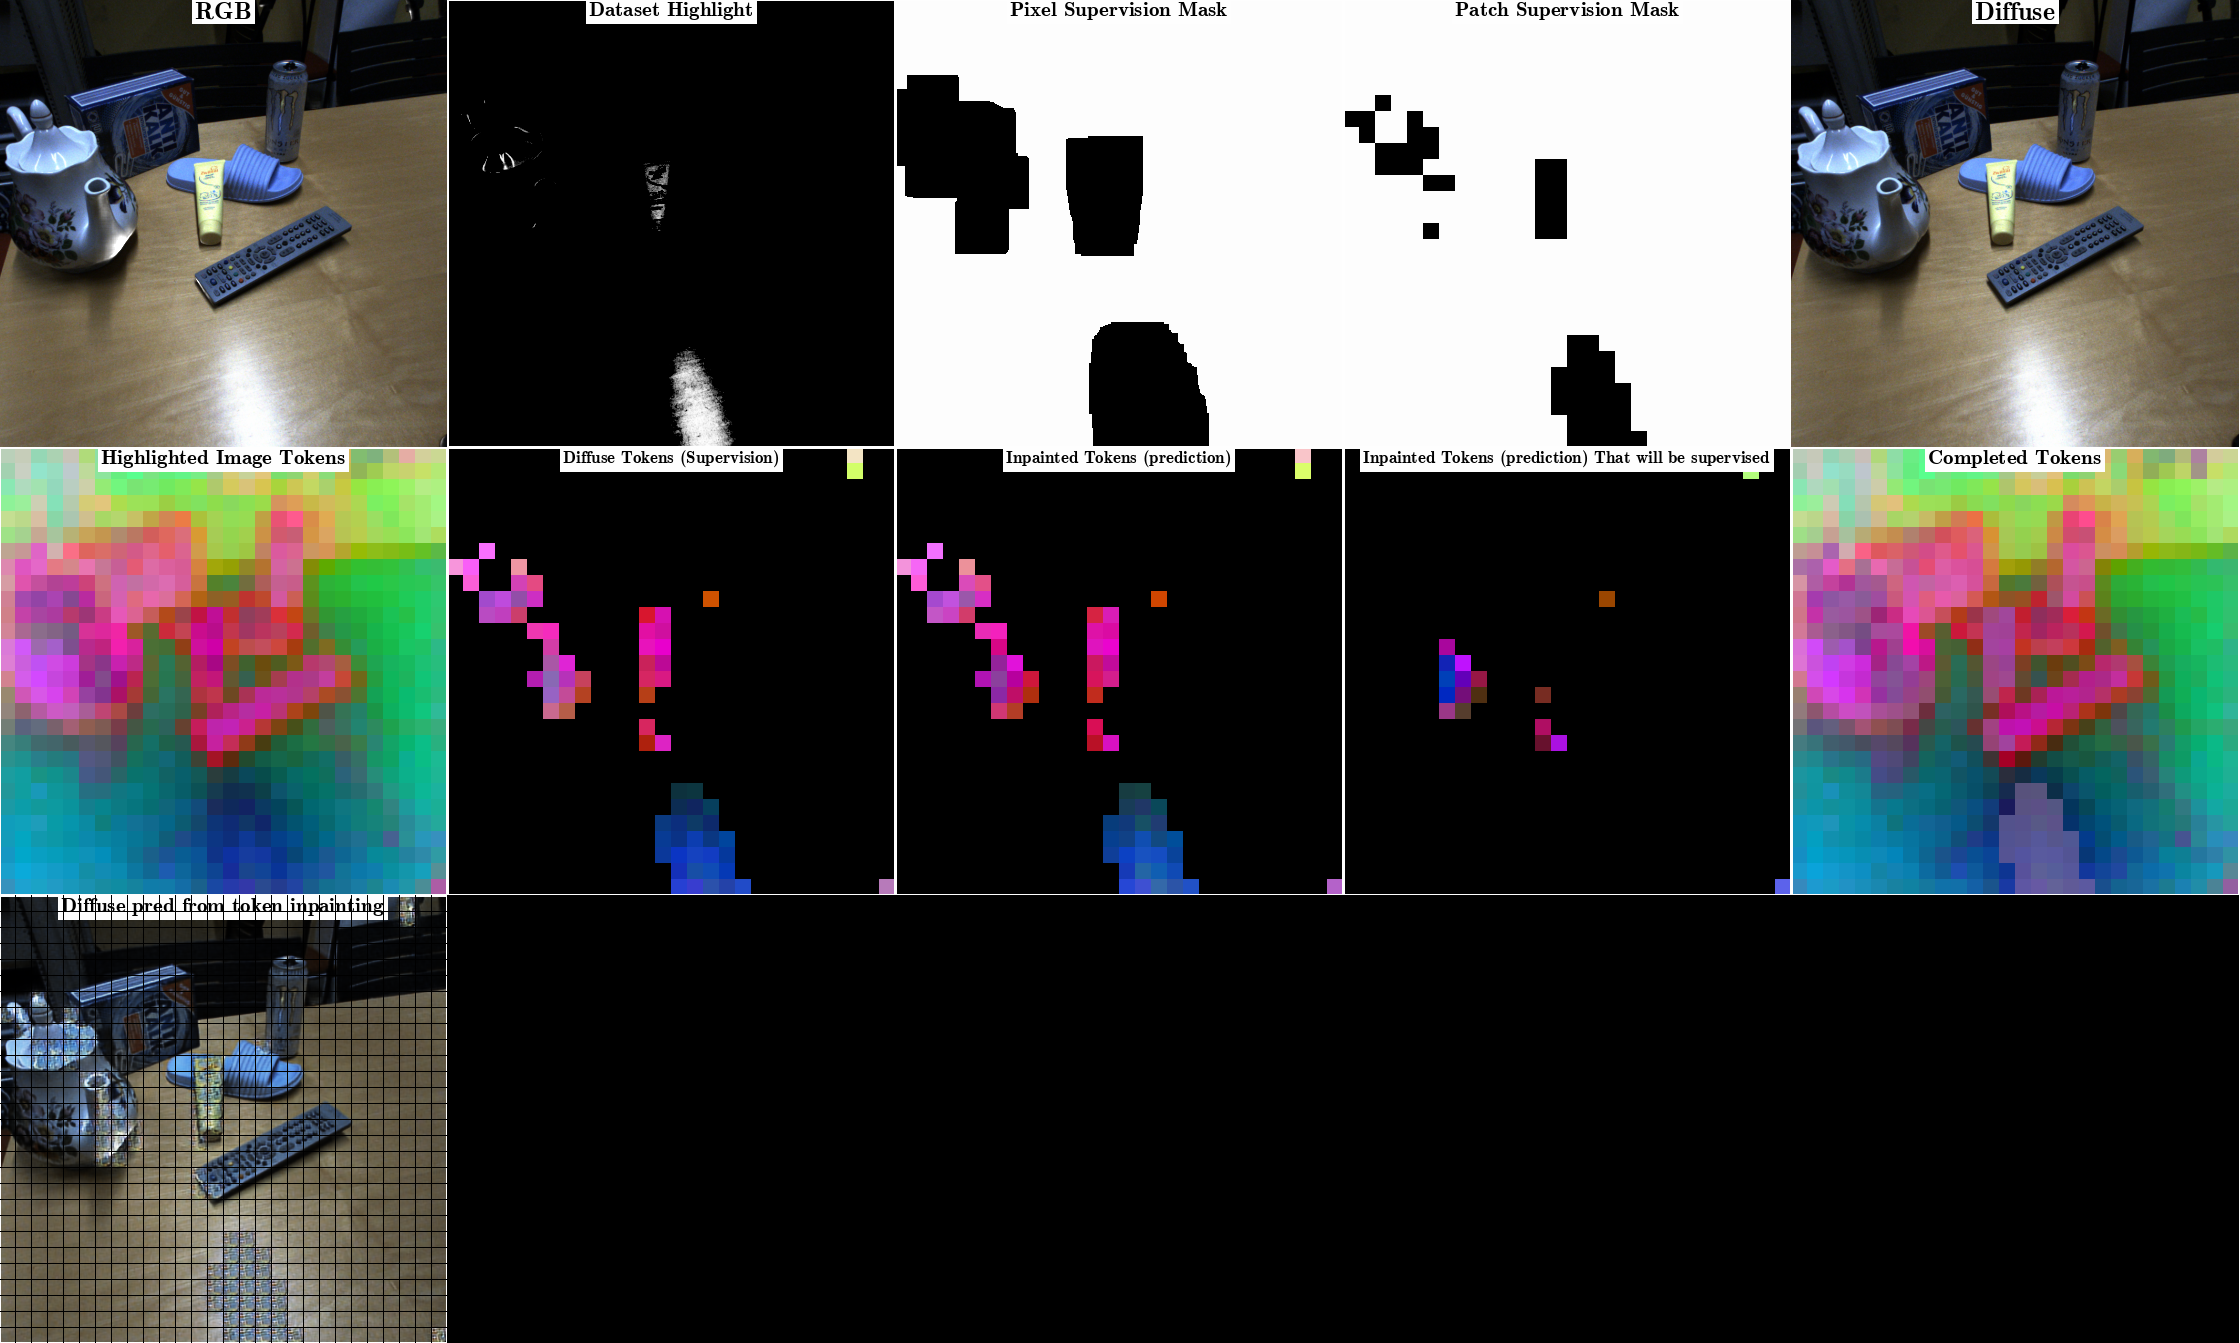

In [33]:
# Refreshing data instance for debug purposes
# idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True))
# batch = next(idataloadr)
config = load_and_process_config("config_train.yaml")


image = batch["raw"].cuda(non_blocking=True)
diffuse = batch["diffuse"].cuda(non_blocking=True)
# Computing highlights
out = ph(
    rgb=image,
    surface_roughness=config.SURFACE_ROUGHNESS,
    intensity=config.INTENSITY,
    return_dataset_highlights=True,
    dataset_highlight_dilation=config.DATASET_HIGHLIGHT_DILATION,
    dataset_highlight_threshold=config.DATASET_HIGHLIGHT_THRESHOLD,
)
patch_supervision_mask = pixel_mask_to_patch_mask(
    out["dataset_highlights_soft_mask"], patch_size=16, threshold=0.1,invert=True
)
pixel_inpaint_mask =  out["highlight"]+out["dataset_highlights_soft_mask"]
### INPAINT ON ALL OF THESE
patch_inpaint_mask = torch.clamp(pixel_mask_to_patch_mask(pixel_inpaint_mask, patch_size=16, threshold=0.1), 0, 1)
# Computing model prediction
diffuse_teacher_tokens = model.extract_tokens(diffuse)
highlighted_tokens = model.extract_tokens(out["rgb_highlighted"])
model_out = model(
    {"rgb": out["rgb_highlighted"], "patch_mask_override": pixel_inpaint_mask}
)

for k, v in model_out.items():
    print(
        k,
        tuple(v.shape)
        if hasattr(v, "shape")
        else f"{len(v)} x {tuple[Any, ...](v[0].shape)}",
    )

_, pca = rgb(
    diffuse_teacher_tokens[-1]
    .reshape(-1, 28, 28, 1024)
    .permute(0, 3, 1, 2)
    .detach(),
    as_tensor=True,
    return_pca=True,
)
rgb(
    panelize(
        rgb(out["rgb_highlighted"], as_tensor=True, label={"text": "RGB"}),
        rgb(
            out["dataset_highlights_soft_mask"],
            colormap="gray",
            as_tensor=True,
            border={"color": "#ffffff"},
            label={"text": "Dataset Highlight"},
        ),
        rgb(
            out["supervision_mask"],
            colormap="gray",
            as_tensor=True,
            border={"color": "#ffffff"},
            label={"text": "Pixel Supervision Mask"},
        ),
        rgb(
            patch_supervision_mask.int().reshape(1, 28, 28),
            colormap="gray",
            as_tensor=True,
            resize=(448, 448),
            border={"color": "#ffffff"},
            label={"text": "Patch Supervision Mask"},
        ),
        rgb(diffuse, as_tensor=True, label={"text": "Diffuse"}),
        rgb(
            highlighted_tokens[-1]
            .reshape(-1, 28, 28, 1024)
            .permute(0, 3, 1, 2)
            .detach(),
            as_tensor=True,
            resize=(448, 448),
            border={"color": "#ffffff"},
            label={"text": "Highlighted Image Tokens"},
            pca=pca,
        ),
        rgb(
            diffuse_teacher_tokens[-1]
            .reshape(-1, 28, 28, 1024)
            .permute(0, 3, 1, 2)
            .detach()
            * patch_inpaint_mask.int().reshape(1, 28, 28),
            as_tensor=True,
            resize=(448, 448),
            border={"color": "#ffffff"},
            label={"text": "Diffuse Tokens (Supervision)"},
            blackout=True,
            pca=pca,
        ),
        rgb(
            model_out["tokens_inpainted"][-1]
            .reshape(-1, 28, 28, 1024)
            .permute(0, 3, 1, 2)
            .detach()
            * patch_inpaint_mask.int().reshape(1, 28, 28),
            as_tensor=True,
            resize=(448, 448),
            border={"color": "#ffffff"},
            label={"text": "Inpainted Tokens (prediction)"},
            pca=pca,
            blackout=True,
        ),
        rgb(
            model_out["tokens_inpainted"][-1]
            .reshape(-1, 28, 28, 1024)
            .permute(0, 3, 1, 2)
            .detach()
            * patch_inpaint_mask.int().reshape(1, 28, 28) * patch_supervision_mask.int().reshape(1, 28, 28),
            as_tensor=True,
            resize=(448, 448),
            border={"color": "#ffffff"},
            label={"text": "Inpainted Tokens (prediction) That will be supervised"},
            pca=pca,
            blackout=True,
        ),
        rgb(
            model_out["tokens_completed"][-1]
            .reshape(-1, 28, 28, 1024)
            .permute(0, 3, 1, 2)
            .detach(),
            as_tensor=True,
            resize=(448, 448),
            border={"color": "#ffffff"},
            label={"text": "Completed Tokens"},
            pca=pca,
        ),
        rgb(
            model_out["diffuse"],
            as_tensor=True,
            resize=(448, 448),
            border={"color": "#ffffff"},
            label={"text": "Diffuse pred from token inpainting"},
            show_grid={"spacing": 16},
        ),
        mode="grid",
        grid_size=(3,5),
    ),
)

In [25]:
print(comp.shape)
print(model_out["patch_mask"].reshape(1, 28, 28).unsqueeze(0).shape)

torch.Size([1, 3, 448, 448])
torch.Size([1, 1, 28, 28])


In [ ]:
model_out["patch_mask"].reshape(1, 28, 28).unique()
model_out["patch_mask"][0, 50:60] = 0

In [32]:
model_out["patch_mask"].unique()

tensor([False,  True], device='cuda:0')

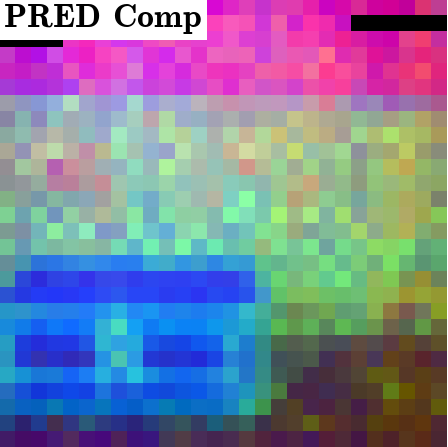

In [ ]:
def make_black_image():
    return torch.zeros(3, 448, 448)


comp = rgb(
    model_out["tokens_teacher"][-1]
    .reshape(-1, 28, 28, 1024)
    .permute(0, 3, 1, 2)
    .detach()
    * model_out["patch_mask"].reshape(1, 28, 28).int(),
    as_tensor=True,
    resize=(448, 448),
    blackout=True,
    interpolation="nearest",
).unsqueeze(0)
pred_decomposition = {"comp": comp}
comp_name = "comp"
rgb(
    pred_decomposition[comp_name][0][:3].detach()
    if comp_name in pred_decomposition
    else make_black_image(),
    # as_tensor=True,
    resize=(448, 448),
    colormap="gray",
    # border={"color": "#ffffff   ", "thickness": 1 if comp_name not in pred_decomposition else 0} ,
    label={
        "position": "top-left",
        "height": 40,
        "margin": 1 if comp_name not in pred_decomposition else 0,
        "text": f"PRED {comp_name.capitalize()}"
        if comp_name in pred_decomposition
        else "NA",
    },
)

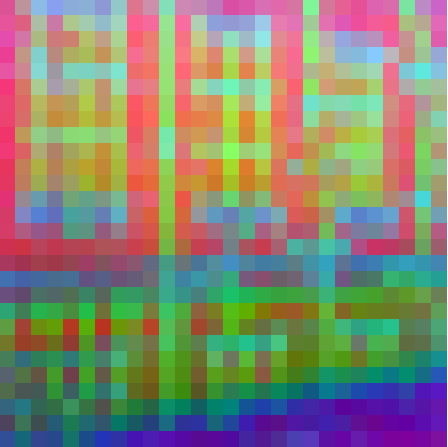

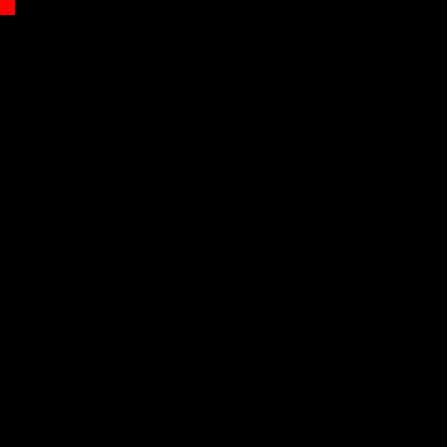

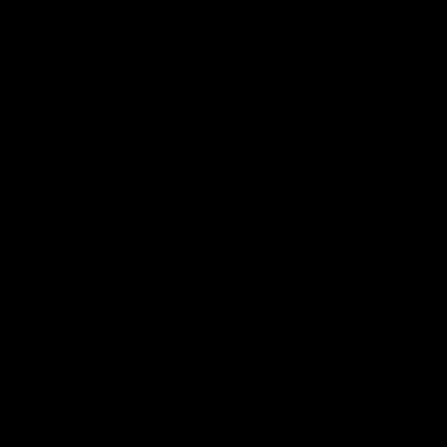

(None,)

In [ ]:
rgb(
    model_out["tokens_teacher"][-1].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2),
    scale=16,
)
rgb(
    model_out["tokens_completed"][-1]
    .reshape(1, 28, 28, 1024)
    .permute(0, 3, 1, 2)
    .detach(),
    scale=16,
)
(rgb(model_out["patch_mask"].int().reshape(1, 28, 28)[0], colormap="gray", scale=16),)
